# 10.1 从生物神经元到人工神经元


---

## 1. 感知器的核心结构

感知器的工作原理可以浓缩为一个简单的公式：
$$Output = \text{step}(\sum_{i=1}^{n} w_i x_i + b)$$

1.  **输入 ($x_i$)**：代表特征（比如图像的像素值）。
2.  **权重 ($w_i$)**：代表每个输入的重要性。
3.  **偏置 ($b$)**：代表触发神经元的难度门槛。
4.  **求和运算**：将所有加权后的输入相加。
5.  **激活函数 (Step Function)**：感知器使用的是典型的“阶跃函数”。如果总和大于 0，输出 1（激活）；否则输出 0（抑制）。

---

##  2. 感知器是如何“学习”的？

感知器通过**犯错**来调整自己。

* 如果模型预测错了，它就会根据误差调整权重 $w$。
* **感知器收敛定理**：如果数据是**线性可分**的（即可以用一条直线切开），感知器一定能找到那条线。

---

## 3. 多层感知器 (MLP) 的诞生

单层感知器有一个致命的缺陷：它无法处理**异或（XOR）问题**。也就是说，如果两类数据点像麻花一样绕在一起，单层感知器就“傻眼”了。

为了解决这个问题，研究者发现：**把多个感知器堆叠起来**，形成“输入层 - 隐藏层 - 输出层”的结构，就能处理复杂的非线性问题。这就是 **MLP (Multi-Layer Perceptron)**。

---


In [1]:
from pickletools import optimize

import keras

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:,(2,3)]
y = (iris.target == 0).astype(int)

per_clf =Perceptron()
per_clf.fit(X,y)

y_pred = per_clf.predict([[2,0.5]])



---

## 1. 多层感知器 (MLP) 的结构

感知器只能处理简单的线性问题，而 MLP 通过“堆叠”打破了这一限制。一个典型的 MLP 包含：

1.  **输入层 (Input Layer)**：接收原始数据（如 784 个像素点）。
2.  **隐藏层 (Hidden Layers)**：一层或多层。这是模型提取抽象特征的地方。层数越多、神经元越多，模型的“胃口”（表达能力）就越大。
3.  **输出层 (Output Layer)**：产生最终结果（如 10 个数字的概率分布）。



> **关键变化**：为了让模型能处理复杂逻辑，MLP 的神经元不再使用感知器那种硬生生的“阶跃函数”，而是改用**平滑的激活函数**（如 ReLU, Sigmoid, Tanh）。

---

## 2. 反向传播 (Backpropagation)：

这是深度学习领域最伟大的算法之一。简单来说，反向传播就是**“根据结果分摊责任”**的过程。

训练过程分为两步循环：

### 第一步：前向传播 (Forward Pass)
数据从输入层进入，经过每一层的加权计算和激活，最后在输出层得到一个预测值。此时，系统会计算预测值与真实值之间的**误差（Loss）**。

### 第二步：反向传播 (Backward Pass)
这是精华所在。算法会从输出层往回走：
1.  计算输出层的误差贡献。
2.  利用**链式法则 (Chain Rule)**，计算上一层每个神经元对这个误差负有多少责任。
3.  依次类推，直到输入层。
4.  最后，使用**梯度下降 (Gradient Descent)** 微调每一层的权重，让误差变小。

---

##  3. 现代 MLP 的标配：激活函数

在第二版教材中，`ReLU` 几乎统治了隐藏层。为什么不用感知器的阶跃函数？
* **阶跃函数**：导数为 0 或不存在，梯度没法传导，反向传播直接“断流”。
* **ReLU (Rectified Linear Unit)**：$f(x) = \max(0, x)$。它在正区间导数为 1，计算极其简单且不会导致梯度消失。

---


## 回归MLP:



## 1. 回归 MLP 的典型架构

回归 MLP 的结构与分类模型类似，但在**输出层**有本质区别：

1.  **输入层**：每个特征一个神经元（例如：加州房价预测中有 8 个特征，则有 8 个输入神经元）。
2.  **隐藏层**：通常使用 `ReLU` 激活函数。层数和每层神经元数量取决于问题的复杂度。
3.  **输出层**：
    * **神经元数量**：通常只有 **1 个**（预测一个连续数值，如房价）。如果是多变量回归（例如同时预测物体的坐标 X 和 Y），则为多个。
    * **激活函数**：通常 **不使用激活函数**。因为我们需要输出任意范围的连续值。
        * *例外*：如果想确保输出永远为正数，可以用 `ReLU`；如果想确保输出在 0 到 1 之间，可以用 `Sigmoid`。

---

## 2. 核心超参数配置

在 Keras 中实现回归 MLP 时，需要特别关注以下三个配置：

| 配置项 | 推荐设置 | 理由 |
| :--- | :--- | :--- |
| **Loss (损失函数)** | `mse` (均值平方误差) | 回归任务的标准度量，对异常值较敏感。 |
| **Metric (指标)** | `rmse` 或 `mae` | `mae` (平均绝对误差) 在存在大量离群点时更稳健。 |
| **Optimizer (优化器)** | `adam` 或 `rmsprop` | 相比 `sgd`，这些自适应学习率优化器在回归任务中收敛更快。 |





---


## 关键提醒：必须进行特征缩放 (Scaling)

在之前的传统机器学习中，某些模型（如决策树）对数据量纲不敏感。但对于 **神经网络**，特征缩放是**生死攸关**的：
* 如果特征 A 范围是 0-1，特征 B 范围是 0-10000，反向传播的梯度会变得极其不稳定。
* **必须在训练前使用 `StandardScaler` 进行标准化**

---
### 典型的回归 MLP 架构

| 超参数                 | 典型值                                                     |
|------------------------|------------------------------------------------------------|
| 输入神经元数量         | 每个输入特征一个（例如，MNIST 为 \(28 \times 28 = 784\)）   |
| 隐藏层数量             | 取决于问题，但通常为 1 到 5                                |
| 每个隐藏层的神经元数量 | 取决于问题，但通常为 10 到 100                             |
| 输出神经元数量         | 每个预测维度输出 1 个神经元                                |
| 隐藏的激活             | ReLU（或 SELU，见第 11 章）                                |
| 输出激活               | 无，或 ReLU/softplus（如果为正输出）或逻辑/tanh（如果为有界输出） |
| 损失函数               | MSE 或 MAE / Huber（如果存在离群值）                       |

---


### 分类MLP

分类 MLP（Classification MLP）是深度学习中最典型的应用场景。

相比回归任务，分类 MLP 在**输出层设计**和**损失函数选择**上有着严格的规范。

---

##  1. 分类 MLP 的典型架构

分类任务根据类别的数量，可以分为**二分类**和**多分类**：

### A. 二分类 (Binary Classification)
* **输出层神经元**：**1个**。
* **输出层激活函数**：**`sigmoid`**。它将输出压缩在 $0$ 到 $1$ 之间，代表属于正类的概率。
* **场景示例**：判断一张图片是不是猫（是/否）。

### B. 多标签二分类 (Multi-label Binary Classification)
* **输出层神经元**：**N个**（对应 N 个可能的独立标签）。
* **输出层激活函数**：**`sigmoid`**。每个神经元独立输出该标签出现的概率。
* **场景示例**：识别一张图片中是否包含“猫”、“狗”、“树”（一张图可以同时有多个）。

### C. 多分类 (Multiclass Classification) —— *第十章重点*
* **输出层神经元**：**10个**（如果是 Fashion MNIST，对应 10 类衣物）。
* **输出层激活函数**：**`softmax`**。它确保所有输出神经元的概率之和等于 **100%**，互斥且穷尽。
* **场景示例**：判断图片是“凉鞋”还是“T恤”。

---

## 2. 损失函数 (Loss Functions) 的选择

在 Keras 中，需要根据标签（Label）的存储格式来选择：

1.  **`binary_crossentropy`**：用于二分类。
2.  **`categorical_crossentropy`**：用于多分类，但要求标签是 **One-hot 编码**（例如：`[0, 0, 1, 0, ...]`）。
3.  **`sparse_categorical_crossentropy`**：用于多分类，且标签是 **整数索引**（例如：`3` 代表裙子，`5` 代表凉鞋）。

---

## 3. 关键超参数：隐层神经元数量

在书中第十章，作者提到了一些经验法则：
* **漏斗状结构**：通常第一层隐藏层神经元最多（如 300），随后的层逐渐减少（如 100）。这是因为低级特征（像素点）较多，而高级抽象特征（轮廓、纹理）较少。
* **过度拟合风险**：如果模型准确率在训练集极高但在验证集很低，说明你的 MLP “太宽”或“太深”了，记住了噪声。

---

## 总结：分类与回归 MLP 的区别

| 特征 | 回归 MLP | 分类 MLP (多分类) |
| :--- | :--- | :--- |
| **输出层神经元** | 1 (或每个维度1个) | 每个类别 1 个 |
| **输出激活函数** | 无 (或 ReLU/Sigmoid) | **Softmax** |
| **损失函数** | MSE / MAE | **Cross Entropy (交叉熵)** |
| **典型指标** | RMSE | **Accuracy (准确率)** |

---


# 10.2 使用Keras实现MLP

In [3]:
import keras

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import tensorflow as tf
from tensorflow import keras
tf.__version__

'2.20.0'

In [6]:
keras.__version__

'3.12.1'

In [7]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [8]:
X_train_full.shape

(60000, 28, 28)

In [9]:
X_train_full.dtype

dtype('uint8')

In [10]:
X_valid,X_train = X_train_full[:5000]/255.0,X_train_full[5000:]/255.0
y_valid,y_train =y_train_full[:5000],y_train_full[5000:]

In [11]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [12]:
class_names[y_train[0]]

'Coat'

建立神经网络：

In [13]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))


可以不用逐层添加层：

In [14]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [15]:
# 显示模型的所有层
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 获取模型层列表
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [17]:
# 按照索引获取层
hidden1 = model.layers[1]
hidden1.name

'dense_3'

In [18]:
# 按照名称获取层
model.get_layer('dense_3') is hidden1

True

In [19]:
# 访问所有参数
weights,biases = hidden1.get_weights()
weights

array([[-2.4490461e-02,  5.2482560e-02,  7.0335820e-02, ...,
        -3.2245964e-03, -3.1938285e-02,  2.9173888e-02],
       [-2.9913668e-02, -7.4132733e-02,  5.0574824e-02, ...,
         5.0999224e-05, -7.2351731e-02, -5.8430068e-02],
       [ 1.4180936e-02, -5.8062859e-02, -5.9269708e-02, ...,
         5.2186668e-02, -6.1474331e-02,  1.6167201e-02],
       ...,
       [-5.1037714e-02,  6.6056833e-02, -6.2841564e-02, ...,
        -6.0286887e-02, -2.1330975e-02, -5.4500975e-02],
       [-4.3292001e-02, -5.6207553e-03, -6.2004991e-02, ...,
         2.5861345e-02,  6.5187410e-02, -6.9892429e-02],
       [-5.4639578e-04, -7.1063749e-02,  7.1070313e-02, ...,
         6.8426982e-02,  6.9979161e-02,  3.2335743e-03]],
      shape=(784, 300), dtype=float32)

In [20]:
weights.shape

(784, 300)

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [22]:
biases.shape

(300,)

权重矩阵的形状取决于输入的个数，所以必须指定input_sahpe()的原因

In [23]:
# 编译模型
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = 'sgd',
              metrics = ['accuracy'])

使用这个指标的原因是具有稀疏标签，并且这些类是互斥的

训练模型

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs = 30,
    validation_data = (X_valid, y_valid),
    verbose=2,  # 每轮只输出1行，不刷屏
)

Epoch 1/30
1719/1719 - 5s - 3ms/step - accuracy: 0.7639 - loss: 0.7125 - val_accuracy: 0.8252 - val_loss: 0.5088
Epoch 2/30
1719/1719 - 5s - 3ms/step - accuracy: 0.8271 - loss: 0.4933 - val_accuracy: 0.8530 - val_loss: 0.4415
Epoch 3/30
1719/1719 - 4s - 3ms/step - accuracy: 0.8431 - loss: 0.4482 - val_accuracy: 0.8504 - val_loss: 0.4322
Epoch 4/30
1719/1719 - 5s - 3ms/step - accuracy: 0.8525 - loss: 0.4204 - val_accuracy: 0.8424 - val_loss: 0.4528
Epoch 5/30
1719/1719 - 4s - 2ms/step - accuracy: 0.8597 - loss: 0.4005 - val_accuracy: 0.8708 - val_loss: 0.3783
Epoch 6/30
1719/1719 - 4s - 2ms/step - accuracy: 0.8634 - loss: 0.3842 - val_accuracy: 0.8682 - val_loss: 0.3778
Epoch 7/30
1719/1719 - 4s - 2ms/step - accuracy: 0.8692 - loss: 0.3704 - val_accuracy: 0.8790 - val_loss: 0.3527
Epoch 8/30
1719/1719 - 4s - 2ms/step - accuracy: 0.8717 - loss: 0.3582 - val_accuracy: 0.8692 - val_loss: 0.3664
Epoch 9/30
1719/1719 - 4s - 2ms/step - accuracy: 0.8770 - loss: 0.3477 - val_accuracy: 0.8768 - 

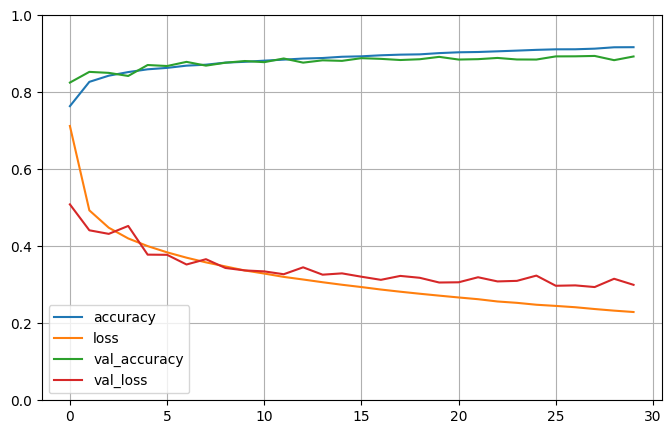

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

学习曲线：每个轮次测得的平均训练损失和准确率，以及每个轮次结束时测得的平均验证损失和准确率


---

### 1. 整体收敛性分析 (Convergence)
从 **Loss 曲线** 和 **Accuracy 曲线** 来看，模型表现非常稳健且符合预期：
* **快速收敛**：在头 5 个 Epoch 左右，Loss 出现了剧烈的下降，Accuracy 快速攀升。这说明学习率（Learning Rate）设置得比较合理，模型正在有效地从 Fashion MNIST 数据中提取特征。
* **平稳期**：在 20 个 Epoch 之后，曲线趋于平缓。此时模型进入了细微调整阶段，收益递减效应开始显现。

---

### 2. 过拟合与欠拟合诊断 (Overfitting vs. Underfitting)
我们需要对比 **Training（实线）** 与 **Validation（虚线）** 的差距：
* **低泛化误差**：训练集准确率和验证集准确率贴合得非常紧密。这说明你的模型目前**没有明显的过拟合**。
* **泛化表现**：验证集（Validation）的表现甚至略好于或等同于训练集，这通常是因为：
    1.  训练集包含了 Dropout 或噪声（如果开启了），而验证集没有。
    2.  验证集相对较小，数据分布恰好比较容易识别。
* **诊断结果**：模型处于“健康状态”。如果训练集准确率继续攀升到 99% 而验证集停留在 85% 并开始掉头向下，那是过拟合发生的信号。

---

### 3. 指标细节观察
* **Loss 阶梯**：观察发现 Loss 曲线非常平滑，没有出现剧烈的震荡。这反映了使用的 **SGD（随机梯度下降）** 或 **Adam 优化器** 工作正常，Batch Size 的选择也支撑了稳定的梯度估计。
* **准确率水平**：最终准确率稳定在 **85% - 90%** 之间。对于简单的多层感知机（MLP）处理 Fashion MNIST 这是一个非常标准的成绩。

---


In [26]:
# 在测试集上评估泛化误差
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8199 - loss: 82.7032


[82.70316314697266, 0.8198999762535095]

使用模型进行预测

In [27]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

对于每一个实例，模型都估计从0类到9类每个类的概率

In [28]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

### 使用顺序API构建回归MLP

In [29]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()

X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [30]:
model = keras.models.Sequential([
    keras.layers.Dense(30,activation='relu',input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss = 'mean_squared_error',optimizer = 'sgd')
history = model.fit(X_train,y_train,epochs = 20,validation_data = (X_valid,y_valid))

mse_test = model.evaluate(X_test,y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7628 - val_loss: 0.5935
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6403 - val_loss: 0.4916
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4597 - val_loss: 0.4745
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4428 - val_loss: 0.4242
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3941 - val_loss: 0.4062
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3861 - val_loss: 0.4045
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3795 - val_loss: 0.4012
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3684 - val_loss: 0.3843
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3622 - val_loss: 0.3760
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3554 - val_loss: 0.3655
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3503 - val_loss: 0.3669
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

## 使用函数式API构建复杂模型

**宽深神经网络 (Wide & Deep Learning)** 由 Google 在 2016 年提出，最初是为了解决应用商店的推荐问题，但后来被证明在**回归任务**中效果极佳。

---

### 1. 为什么要“又宽又深”？

传统的神经网络（Deep）虽然擅长学习复杂的特征组合，但有时会“过度泛化”，忽略掉数据中简单、直接的逻辑。

* **宽模型 (Wide)**：
    * **结构**：输入直接连接到输出层。
    * **作用**：**强记 (Memorization)**。它能记住数据中简单的线性规则或频繁出现的特征组合（例如：邮政编码 90210 的房子通常很贵）。
* **深模型 (Deep)**：
    * **结构**：经过多层隐藏层的堆叠。
    * **作用**：**泛化 (Generalization)**。它能挖掘特征之间隐藏的、非线性的复杂关系。

---

### 2. 物理结构：跨接 (Skip Connection)

可以把 Wide & Deep 想象成给原本的深度网络加了一条“快车道”。
一部分特征（或者全部特征）绕过了深度隐藏层，直接和深度路径的输出汇合，最后一起进入输出层。

这种结构允许模型既能处理非线性的复杂模式，又不会丢掉最直观的线性特征。

---

### 3. 进阶版：多输入 (Multiple Inputs)

**给 Wide 路径和 Deep 路径喂不同的特征**。
* **Wide 路径**：输入简单的、原始的特征（比如房屋年龄）。
* **Deep 路径**：输入复杂的特征（比如经纬度坐标，让深度网络去学习地理位置的非线性分布）。

这要求在 `model.fit()` 时传入两个输入向量：`model.fit((X_train_A, X_train_B), y_train, ...)`。

---


In [31]:
input_ = keras.layers.Input(shape = X_train.shape[1:])
hidden1 = keras.layers.Dense(30,activation='relu')(input_)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input_,hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs = input_, outputs = [output])

In [32]:
input_A = keras.layers.Input(shape = [5],name = 'wide_input')
input_B = keras.layers.Input(shape = [6],name = 'deep_input')
hidden1 = keras.layers.Dense(30,activation='relu')(input_B)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input_A,hidden2])
output = keras.layers.Dense(1,name = 'output')(concat)
model = keras.Model(inputs = [input_A,input_B], outputs = output)

In [33]:
model.compile(
    loss = 'mse',
    optimizer=keras.optimizers.SGD(learning_rate = 1e-3)
)

X_train_A,X_train_B = X_train[:,:5],X_train[:,2:]
X_valid_A,X_valid_B = X_valid[:,:5],X_valid[:,2:]
X_test_A,X_test_B = X_test[:,:5],X_test[:,2:]
X_new_A,X_new_B = X_test_A[:3],X_test_B[:3]

history = model.fit((X_train_A,X_train_B),y_train,epochs = 20,validation_data = ((X_valid_A,X_valid_B),y_valid))
mse_test = model.evaluate((X_test_A,X_test_B),y_test)
y_pred = model.predict((X_new_A,X_new_B))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9473 - val_loss: 0.8527
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7262 - val_loss: 0.7000
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6523 - val_loss: 0.6549
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6192 - val_loss: 0.6274
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5955 - val_loss: 0.6076
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5773 - val_loss: 0.5920
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5617 - val_loss: 0.5791
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5487 - val_loss: 0.5665
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5374 - val_loss: 0.5591
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5281 - val_loss: 0.5477
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5204 - val_loss: 0.5406
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [34]:
output = keras.layers.Dense(1,name = 'main_output')(concat)
aux_output = keras.layers.Dense(1,name = 'aux_output')(hidden2)
model = keras.Model(inputs = [input_A,input_B], outputs = [output,aux_output])

In [35]:
model.compile(loss = ['mse','mse'],loss_weights = [0.9,0.1],optimizer = 'sgd')

In [36]:
history = model.fit(
    [X_train_A,X_train_B],
    [y_train,y_train],
    epochs = 20,
    validation_data = ([X_valid_A,X_valid_B],[y_valid,y_valid]))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 1.6726 - loss: 0.9046 - main_output_loss: 0.8192 - val_aux_output_loss: 0.9217 - val_loss: 0.5709 - val_main_output_loss: 0.5318
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 0.8547 - loss: 0.5394 - main_output_loss: 0.5042 - val_aux_output_loss: 0.8277 - val_loss: 0.5215 - val_main_output_loss: 0.4874
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 0.7802 - loss: 0.5291 - main_output_loss: 0.5011 - val_aux_output_loss: 0.7663 - val_loss: 0.5126 - val_main_output_loss: 0.4843
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 0.7233 - loss: 0.4822 - main_output_loss: 0.4554 - val_aux_output_loss: 0.7255 - val_loss: 0.4933 - val_main_output_loss: 0.4674
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 0.6903 - loss: 0.4670 - main_output_loss: 0.4421 - val_aux_output_loss: 0.7090 - val_loss: 0.4856 - val_main_output_loss: 0.4606


# 使用子类API构建动态模型

In [37]:
# class WideAndDeepModel(keras.Model):
#     def __init__(self,units = 30,activation = 'relu',**kwargs):
#         super().__init__(**kwargs)
#         self.hidden1 = keras.layers.Dense(units,activation = activation)
#         self.hidden2 = keras.layers.Dense(units,activation = activation)
#         self.main_output = keras.layers.Dense(1)
#         self.aux_output = keras.layers.Dense(1)
#
#     def call(self,inputs):
#         input_A,input_B = inputs
#         hidden1 = self.hidden1(input_B)
#         hidden2 = self.hidden2(hidden1)
#         concat = keras.layers.Concatenate()([input_A,hidden2])
#         main_output = self.main_output(concat)
#         aux_output = self.aux_output(hidden2)
#         return main_output,aux_output
#
# model = WideAndDeepModel()
# 必须先定义这个类，加载时才能找到
import keras
@keras.saving.register_keras_serializable()  # 新版Keras必须加这个装饰器！
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.output_layer = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        return self.output_layer(concat)

    # 必须加get_config，新版Keras序列化需要
    def get_config(self):
        config = super().get_config()
        config.update({
            "units": 30,
            "activation": "relu"
        })
        return config

    # 必须加from_config，新版Keras反序列化需要
    @classmethod
    def from_config(cls, config):
        return cls(**config)


## 保存和还原模型

In [38]:
model.save('my_keras_model.keras')

In [39]:
from keras.utils import custom_object_scope

# 用custom_object_scope包裹加载，告诉Keras这个自定义类
with custom_object_scope({'WideAndDeepModel': WideAndDeepModel}):
    model = keras.models.load_model('my_keras_model.keras')

## 使用回调函数

In [40]:
# 定义模型
model = keras.Sequential([
    keras.layers.Dense(30,activation = 'relu',input_shape = [8]),
    keras.layers.Dense(30,activation = 'relu'),
    keras.layers.Dense(1)
])

# 编译模型
model.compile(
    loss = 'mse',
    optimizer = keras.optimizers.SGD(learning_rate = 1e-3)
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('my_keras_model.keras')
history = model.fit(X_train,y_train,epochs = 10,callbacks = [checkpoint_cb])

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9105
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9195
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7430
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7047
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6794
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6585
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6397
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6230
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6079
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5940


In [41]:
# 实现提前停止
check_point_cb = keras.callbacks.ModelCheckpoint('my_keras_model.keras',save_best_only=True)
history = model.fit(X_train,y_train,epochs = 10,validation_data = (X_valid,y_valid),callbacks = [check_point_cb])
model = keras.models.load_model('my_keras_model.keras')

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5809 - val_loss: 0.6065
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5689 - val_loss: 0.5965
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5572 - val_loss: 0.5840
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5470 - val_loss: 0.5746
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5369 - val_loss: 0.5652
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5282 - val_loss: 0.5543
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5192 - val_loss: 0.5489
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5110 - val_loss: 0.5411
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5030 - val_loss: 0.5311
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4966 - val_loss: 0.5234


In [42]:
# 实现提前停止的另一种方法，EarlyStopping回调
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(X_train,
                    y_train,
                    epochs = 100,
                    validation_data = (X_valid,y_valid),
                    callbacks = [early_stopping_cb])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4903 - val_loss: 0.5179
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4840 - val_loss: 0.5115
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4788 - val_loss: 0.5086
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4734 - val_loss: 0.5021
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4696 - val_loss: 0.4964
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4657 - val_loss: 0.4927
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4605 - val_loss: 0.4889
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4584 - val_loss: 0.4870
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4539 - val_loss: 0.4811
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4508 - val_loss: 0.4861
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4471 - val_loss: 0.4766
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

In [43]:
# 自定义回调,检验验证损失和训练损失之间的比率（检验过拟合）
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_train_begin(self, epoch,logs):
        print('\nval/train:{:.2f}'.format(logs['val_loss']/logs['loss']))

## 使用TensorBroad进行可视化

In [44]:
# 首先定义根日志文件
import os
root_logdir =os.path.join(os.curdir, 'my_logs')

def get_run_logdir():
    import time
    run_id = time.strftime('run_%Y_%m_%d_%H_%M_%S')
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

In [45]:
# TensorBroad()回调
model = keras.Sequential([
    keras.layers.Dense(30,activation = 'relu',input_shape = [8]),
    keras.layers.Dense(30,activation = 'relu'),
    keras.layers.Dense(1)
])

model.compile(
    loss = 'mse',
    optimizer = keras.optimizers.SGD(learning_rate = 3e-3)
)

tensorboard_cb = keras.callbacks.TensorBoard(log_dir = run_logdir)
history = model.fit(
    X_train,
    y_train,
    epochs = 30,
    validation_data = (X_valid,y_valid),
    callbacks = [tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1542 - val_loss: 0.6298
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5873 - val_loss: 0.5888
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5606 - val_loss: 0.5494
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5174 - val_loss: 0.5299
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4928 - val_loss: 0.5095
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4804 - val_loss: 0.4979
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4676 - val_loss: 0.4909
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4552 - val_loss: 0.4751
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4470 - val_loss: 0.4645
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4462 - val_loss: 0.4598
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4446 - val_loss: 0.4508
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [46]:
# 底层API
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)
with writer.as_default():
    for step in range(1,1000+1):
        tf.summary.scalar('my_scaler',np.sin(step/10),step = step)
        data = (np.random.randn(100)+2)
        tf.summary.histogram('my_histogram',data,buckets=50,step = step)
        images = np.random.randn(2,32,32,3)
        tf.summary.image('my_images',images*step/1000,step = step)
        texts = ['The step is'+str(step),'Its squate is'+str(step**2)]
        tf.summary.text('my_texts',texts,step = step)
        sine_wave = tf.math.sin(tf.range(12000)/48000*2*np.pi*step)
        audio = tf.reshape(tf.cast(sine_wave,tf.float32),[1,-1,1])
        tf.summary.audio('mu_audio',audio,sample_rate=48000,step = step)

## 微调神经网络超参数

In [47]:
def build_model(n_hidden = 1,n_neurons =30,learning_rate = 3e-3,input_shape = [8]):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons,activation = 'relu'))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate = learning_rate,clipnorm=1.0)
    model.compile(loss = 'mse',optimizer = optimizer)
    return model

In [48]:
# 把神经网络包装成sklearn模型
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(build_model)

In [49]:
# 训练并预测
keras_reg.fit(X_train,y_train,epochs = 100,validation_data = (X_valid,y_valid),callbacks = [keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)])
mse_test = keras_reg.score(X_test,y_test)
y_pred = keras_reg.predict(X_new)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2904 - val_loss: 1.0629
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8229 - val_loss: 0.6412
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6268 - val_loss: 0.5784
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5638 - val_loss: 0.5455
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5254 - val_loss: 0.5255
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5024 - val_loss: 0.5104
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4916 - val_loss: 0.4984
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4830 - val_loss: 0.4904
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4745 - val_loss: 0.4834
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4710 - val_loss: 0.4780
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4638 - val_loss: 0.4733
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

In [50]:
# 由于超参数众多，最好是用随机搜索
# 探索隐藏层的数量，神经元的数量和学习率
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    'model__n_hidden':[1,2,3],
    'model__n_neurons':np.arange(10,60,10),
    'model__learning_rate':reciprocal(3e-4,3e-3),
}

rnd_search_cv = RandomizedSearchCV(
    keras_reg,
    param_distributions = param_distribs,
    n_iter=3,
    cv=2,
    verbose=2,
    n_jobs=1)

rnd_search_cv.fit(X_train,
                  y_train,
                  epochs = 50,
                  validation_data = (X_valid, y_valid),
                  callbacks = [keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)])

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Epoch 1/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.6904 - val_loss: 0.9605
Epoch 2/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8472 - val_loss: 0.7494
Epoch 3/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7362 - val_loss: 0.6766
Epoch 4/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6771 - val_loss: 0.6380
Epoch 5/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6425 - val_loss: 0.6127
Epoch 6/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6136 - val_loss: 0.5960
Epoch 7/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5928 - val_loss: 0.5791
Epoch 8/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5757 - val_loss: 0.5643
Epoch 9/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5594 - val_loss: 0.5533
Epoch 10/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5468 - val_loss: 0.5421
Epoch 11/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5341 - val_loss: 

,estimator,KerasRegresso...se epochs=1 )
,param_distributions,"{'model__learning_rate': <scipy.stats....001820D882E60>, 'model__n_hidden': [1, 2, ...], 'model__n_neurons': array([10, 20, 30, 40, 50])}"
,n_iter,3
,scoring,None
,n_jobs,1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [51]:
rnd_search_cv.best_params_

{'model__learning_rate': np.float64(0.0023383784197985136),
 'model__n_hidden': 3,
 'model__n_neurons': np.int64(20)}

In [52]:
rnd_search_cv.best_score_

np.float64(0.6769804908960511)

### 隐藏层的数量

对于许多的问题，仅仅从一两个隐藏层开始，然后神经网络就可以正常工作

### 每个隐藏层的神经元数量

- 输入层和输出层中神经元的数量取决于任务所需的输入类型和输出类型
- 根据数据集有时使第一个隐藏层大于其他的隐藏层是有帮助的
- 可以尝试逐渐增加神经元的数量，直到网络过拟合为止。也可以选择一个比实际需要的层和神经元更多的模型，然后使用提前停止技术和正则化技术来防止模型过拟合

### 学习率，批量大小和其他超参数


---

## 一、核心超参数详解
### 1. 学习率（Learning Rate）
- **地位**：被称为**最重要的超参数**，直接决定模型训练的收敛性与最终效果。
- **调优原则**：
  - 通用经验：最佳学习率约为「最大学习率（算法发散的临界值）的一半」。
  - 科学调参方法：从极低学习率（如 \(10^{-5}\)）开始，逐步增大（如每次迭代乘以恒定因子，500次迭代内从 \(10^{-5}\) 到 \(10\)），绘制「损失-学习率（对数坐标）」曲线，选择**损失开始攀升点前约10倍**的学习率作为最优值，再用该值重新训练模型。
  - 进阶技术：第11章会介绍更多学习率相关优化方法（如学习率调度、初始化策略）。

### 2. 优化器（Optimizer）
- 选择比普通小批量梯度下降（SGD）更优的优化器（如Adam、RMSprop等），并针对性调优其超参数，对模型性能提升至关重要，相关内容在第11章详细展开。

### 3. 批量大小（Batch Size）
- **核心影响**：同时影响模型性能、训练时间与泛化能力。
- **硬件优势**：大批次（Large Batch）可充分利用GPU等硬件加速，提升每秒处理的样本数，缩短训练时间。
- **实践争议与建议**：
  - 主流观点（Yann LeCun等）：**优先使用小批量（2~32）**，小批量能在更短训练时间内获得泛化能力更强的模型，避免大批次导致的训练不稳定、泛化能力下降。
  - 补充方案：若使用大批次，可通过「逐步提高学习率」等技术弥补泛化差距，实现训练效率与效果的平衡。
  - 调参策略：先尝试大批次，若训练不稳定/效果差，再切换为小批量。

### 4. 激活函数（Activation Function）
- **隐藏层默认选择**：**ReLU激活函数**是绝大多数场景的最优默认选择。
- **输出层规则**：激活函数需根据任务类型选择（如分类任务用softmax、回归任务用线性激活）。

### 5. 迭代次数（Epochs）
- 调优原则：**无需手动调整迭代次数，使用「提前停止（Early Stopping）」即可**，避免过拟合。
- 联动注意：学习率的最优值依赖批量大小等其他超参数，修改任意超参数后，需重新调整学习率。

---

## 二、补充建议与延伸
1.  **超参数调优最佳实践**：推荐参考Leslie Smith 2018年的论文，系统学习神经网络超参数调优方法。
2.  **后续内容预告**：后续章节将深入讲解：
    - 深度网络训练技术、TensorFlow底层API自定义模型、Data API数据加载与预处理；
    - 其他主流神经网络架构：卷积神经网络（CNN，图像处理）、循环神经网络（RNN，序列数据）、自动编码器（表征学习）、生成式对抗网络（GAN，生成数据）等。

---

## 三、核心知识点提炼（速记版）
| 超参数 | 核心结论 | 调优关键 |
|--------|----------|----------|
| 学习率 | 最重要超参数，决定收敛性 | 取最大发散学习率的1/2，或用「损失-学习率曲线」找最优值 |
| 批量大小 | 影响训练速度与泛化能力 | 优先小批量（2~32），大批次需配合学习率调整 |
| 激活函数 | 隐藏层默认ReLU，输出层按任务选 | ReLU是通用最优默认选择 |
| 迭代次数 | 无需手动调，用提前停止 | 避免过拟合，联动调整学习率 |

---